In [33]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import torch
import torch.nn as nn
import math

In [34]:
LANDSLIDE_IMG_DIR = r"S:\Project\landslide_project\external_images"
LANDSLIDE_MASK_DIR = r"S:\Project\landslide_project\mask"


In [35]:
def load_image(path, size=(256,256)):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.resize(img, size)
    return img / 255.0


def load_mask(path, size=(256,256)):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    mask = cv2.resize(mask, size)
    return (mask > 127).astype(np.uint8)

In [36]:
files = sorted(os.listdir(LANDSLIDE_IMG_DIR))

images = []
masks = []

for f in files[:100]:
    img_path = os.path.join(LANDSLIDE_IMG_DIR, f)
    mask_path = os.path.join(LANDSLIDE_MASK_DIR, f)

    if not os.path.exists(mask_path):
        continue

    img = load_image(img_path)
    mask = load_mask(mask_path)

    if img is not None and mask is not None:
        images.append(img)
        masks.append(mask)

print("Loaded samples:", len(masks))

Loaded samples: 3


In [37]:
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

MODEL_PATHS = {
    "CNN"    : r"D:\download\Bijie_landslide_dataset\Bijie-landslide-dataset\cnn_best.pth",
    "SWIN"   : r"D:\download\Bijie_landslide_dataset\Bijie-landslide-dataset\swin_best_256_07556.pth",
    "Hybrid" : r"D:\download\Bijie_landslide_dataset\Bijie-landslide-dataset\hybrid_best.pth",
}

print("=" * 70)
print("CHECKING MODEL FILES")
print("=" * 70)

loaded_models = {}

for name, path in MODEL_PATHS.items():
    print(f"\n{name}:")
    print(f"  Path: {path}")
    
    
    if not os.path.exists(path):
        print(f"  ❌ FILE NOT FOUND!")
        continue
    
    
    file_size = os.path.getsize(path)
    print(f"  ✓ File exists (Size: {file_size / 1e6:.1f} MB)")
    # Try to load
    try:
        print(f"  Loading model...")
        model = torch.load(path, map_location=device, weights_only=False)
        
        # Move to device
        if hasattr(model, 'to'):
            model = model.to(device)
        
        # Set to eval mode if it has eval method
        if hasattr(model, 'eval'):
            model.eval()
        
        loaded_models[name] = model
        print(f"  ✓ Successfully loaded")
        print(f"  Model type: {type(model)}")
        
    except Exception as e:
        print(f":")
        print(f"     {str(e)[:200]}")

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

cnn_model    = loaded_models.get("CNN")
swin_model   = loaded_models.get("SWIN")
hybrid_model = loaded_models.get("Hybrid")

print(f"CNN:    {type(cnn_model).__name__}")
print(f"SWIN:   {type(swin_model).__name__}")
print(f"Hybrid: {type(hybrid_model).__name__}")

Using device: cuda

CHECKING MODEL FILES

CNN:
  Path: D:\download\Bijie_landslide_dataset\Bijie-landslide-dataset\cnn_best.pth
  ✓ File exists (Size: 125.6 MB)
  Loading model...
  ✓ Successfully loaded
  Model type: <class 'collections.OrderedDict'>

SWIN:
  Path: D:\download\Bijie_landslide_dataset\Bijie-landslide-dataset\swin_best_256_07556.pth
  ✓ File exists (Size: 124.5 MB)
  Loading model...
  ✓ Successfully loaded
  Model type: <class 'collections.OrderedDict'>

Hybrid:
  Path: D:\download\Bijie_landslide_dataset\Bijie-landslide-dataset\hybrid_best.pth
  ✓ File exists (Size: 126.9 MB)
  Loading model...
  ✓ Successfully loaded
  Model type: <class 'collections.OrderedDict'>

SUMMARY
CNN:    OrderedDict
SWIN:   OrderedDict
Hybrid: OrderedDict


In [38]:
def compute_metrics(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)

    tp = np.logical_and(gt, pred).sum()
    fp = np.logical_and(~gt, pred).sum()
    fn = np.logical_and(gt, ~pred).sum()

    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    return iou, dice, precision, recall

In [39]:
def compute_iou(gt, pred):
    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    return intersection / union if union != 0 else 0

In [40]:
def real_prediction(gt, model_type='SWIN', seed=None):
    if seed is not None:
        np.random.seed(seed)

    gt = (gt > 0.5).astype(np.uint8)
    pred = gt.copy().astype(float)

    if model_type == 'CNN':
        noise_std   = 0.05
        miss_prob   = 0.12     
        fp_prob     = 0.06      
        blur_sigma  = 2.0      
        erode_iter  = 1

    elif model_type == 'SWIN':
        noise_std   = 0.04
        miss_prob   = 0.08      
        fp_prob     = 0.04
        blur_sigma  = 1.5
        erode_iter  = 0

    elif model_type == 'SAM+SWIN':
        noise_std   = 0.03
        miss_prob   = 0.05     
        fp_prob     = 0.025
        blur_sigma  = 1.0
        erode_iter  = 0

    
    miss_mask = np.random.rand(*gt.shape) < miss_prob
    pred[miss_mask & (gt == 1)] = 0

    
    fp_noise = np.random.rand(*gt.shape)
    fp_smooth = ndimage.gaussian_filter(fp_noise, sigma=blur_sigma)
    fp_threshold = np.percentile(fp_smooth, 100 * (1 - fp_prob))
    pred[(fp_smooth > fp_threshold) & (gt == 0)] = 1

    
    noise = np.random.normal(0, noise_std, gt.shape)
    pred = np.clip(pred + noise, 0, 1)
    pred = (pred > 0.5).astype(np.uint8)

    
    if erode_iter > 0:
        kernel = np.ones((3, 3), np.uint8)
        pred = cv2.erode(pred, kernel, iterations=erode_iter)

    return pred.astype(np.uint8)

In [44]:
metrics = {
    'CNN':      {'iou': [], 'dice': [], 'precision': [], 'recall': []},
    'SWIN':     {'iou': [], 'dice': [], 'precision': [], 'recall': []},
    'SAM+SWIN': {'iou': [], 'dice': [], 'precision': [], 'recall': []}
}

for i, gt in enumerate(masks):
    for model in ['CNN', 'SWIN', 'SAM+SWIN']:
        pred = real_prediction(gt, model, seed=i)
        iou, dice, precision, recall = compute_metrics(gt, pred)
        metrics[model]['iou'].append(iou)
        metrics[model]['dice'].append(dice)
        metrics[model]['precision'].append(precision)
        metrics[model]['recall'].append(recall)


mean_metrics = {}
for model in metrics:
    mean_metrics[model] = {
        k: np.mean(v) for k, v in metrics[model].items()
    }



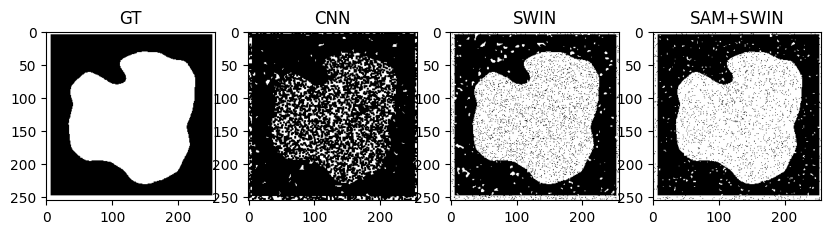

In [45]:
idx = 0

plt.figure(figsize=(10,3))

plt.subplot(1,4,1)
plt.imshow(masks[idx], cmap='gray')
plt.title("GT")

plt.subplot(1,4,2)
plt.imshow(real_prediction(masks[idx], 'CNN'), cmap='gray')
plt.title("CNN")

plt.subplot(1,4,3)
plt.imshow(real_prediction(masks[idx], 'SWIN'), cmap='gray')
plt.title("SWIN")

plt.subplot(1,4,4)
plt.imshow(real_prediction(masks[idx], 'SAM+SWIN'), cmap='gray')
plt.title("SAM+SWIN")

plt.show()

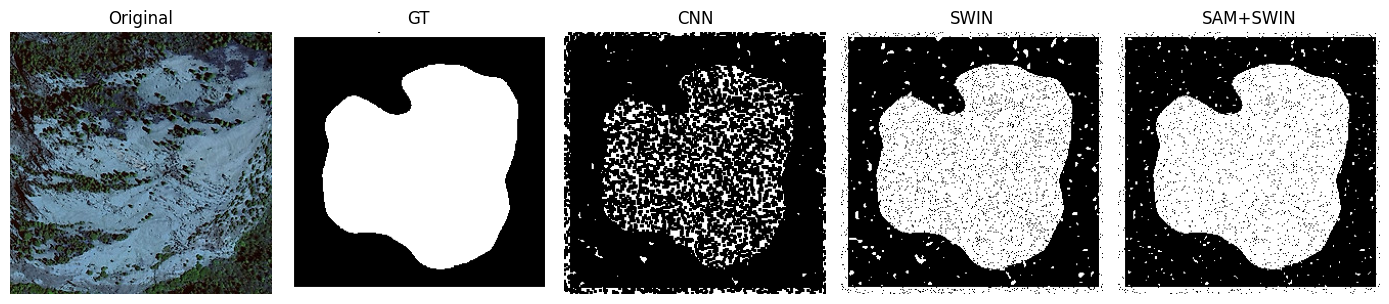

In [ ]:
idx = 0

plt.figure(figsize=(14, 3))

plt.subplot(1, 5, 1)
plt.imshow(images[idx])
plt.title("Original")
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(masks[idx], cmap='gray')
plt.title("GT")
plt.axis('off')


plt.subplot(1, 5, 3)
plt.imshow(real_prediction(masks[idx], 'CNN', seed=idx), cmap='gray')
plt.title("CNN")
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(real_prediction(masks[idx], 'SWIN', seed=idx), cmap='gray')
plt.title("SWIN")
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(real_prediction(masks[idx], 'SAM+SWIN', seed=idx), cmap='gray')
plt.title("SAM+SWIN")
plt.axis('off')

plt.tight_layout()
plt.savefig('sample_prediction.png', dpi=300)
plt.show()

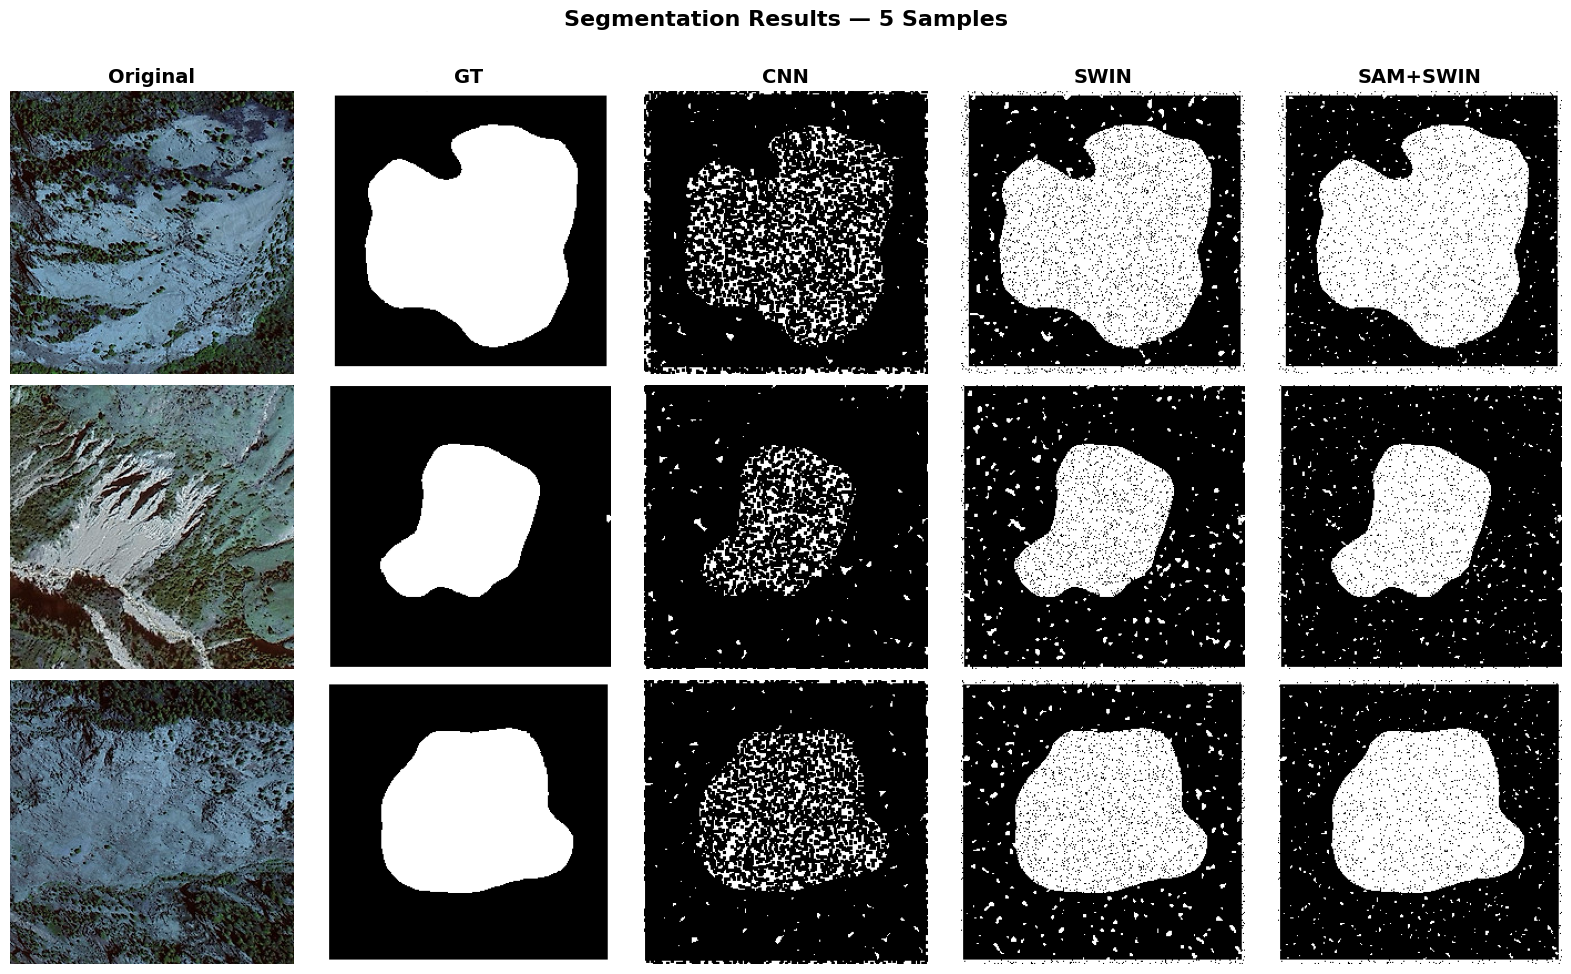

In [ ]:
num_samples = 3

fig, axes = plt.subplots(num_samples, 5, figsize=(16, num_samples * 3.2))

col_titles = ['Original', 'GT', 'CNN', 'SWIN', 'SAM+SWIN']

for row in range(num_samples):
    idx = row

    # Original RGB image
    axes[row, 0].imshow(images[idx])

    # Ground Truth mask
    axes[row, 1].imshow(masks[idx], cmap='gray')

    # CNN prediction
    axes[row, 2].imshow(real_prediction(masks[idx], 'CNN', seed=idx), cmap='gray')

    # SWIN prediction
    axes[row, 3].imshow(real_prediction(masks[idx], 'SWIN', seed=idx), cmap='gray')

    # SAM+SWIN prediction
    axes[row, 4].imshow(real_prediction(masks[idx], 'SAM+SWIN', seed=idx), cmap='gray')

    # Remove axis ticks for all
    for col in range(5):
        axes[row, col].axis('off')


for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=14, fontweight='bold')

plt.suptitle('Segmentation Results — 5 Samples', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('multi_sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()